In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [71]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
print(matplotlib.__version__)

3.6.3


In [72]:
DEBUG = True

In [73]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

# readable legend keys
id_to_readable = {
    "ideal": "Ideal",
    "content": "Content Filtering",
    "content_chaney": "Chaney's Content Filtering",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

In [74]:
folder_paths = ["user_metrics_results"]

In [75]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()

In [76]:
len(final_results['user_distance_to_mean']['chaney_content'])

6

In [77]:
model_keys = ["ideal", "content", "chaney_content", "pop", "mf", "sf", "random"]
metric_list = [
        "user_distance_to_mean",
        "user_mean_distance_to_consumed_items",
        "user_variance_distance_to_consumed_items",
        "user_total_utility",
        ]

In [78]:
all_results = []
i = 0
b = True
while b:
    sim_results_df = pd.DataFrame([])
    for mo in model_keys:
        df = pd.DataFrame([], columns=['model'])
        for me in metric_list:
            users_data = final_results[me][mo][i]
            b = False if i == (len(final_results[me][mo]) - 1) else True
            df[me] = users_data
        df['model'] = mo
        sim_results_df = pd.concat([sim_results_df, df], ignore_index=True)
    all_results.append(sim_results_df)
    i += 1

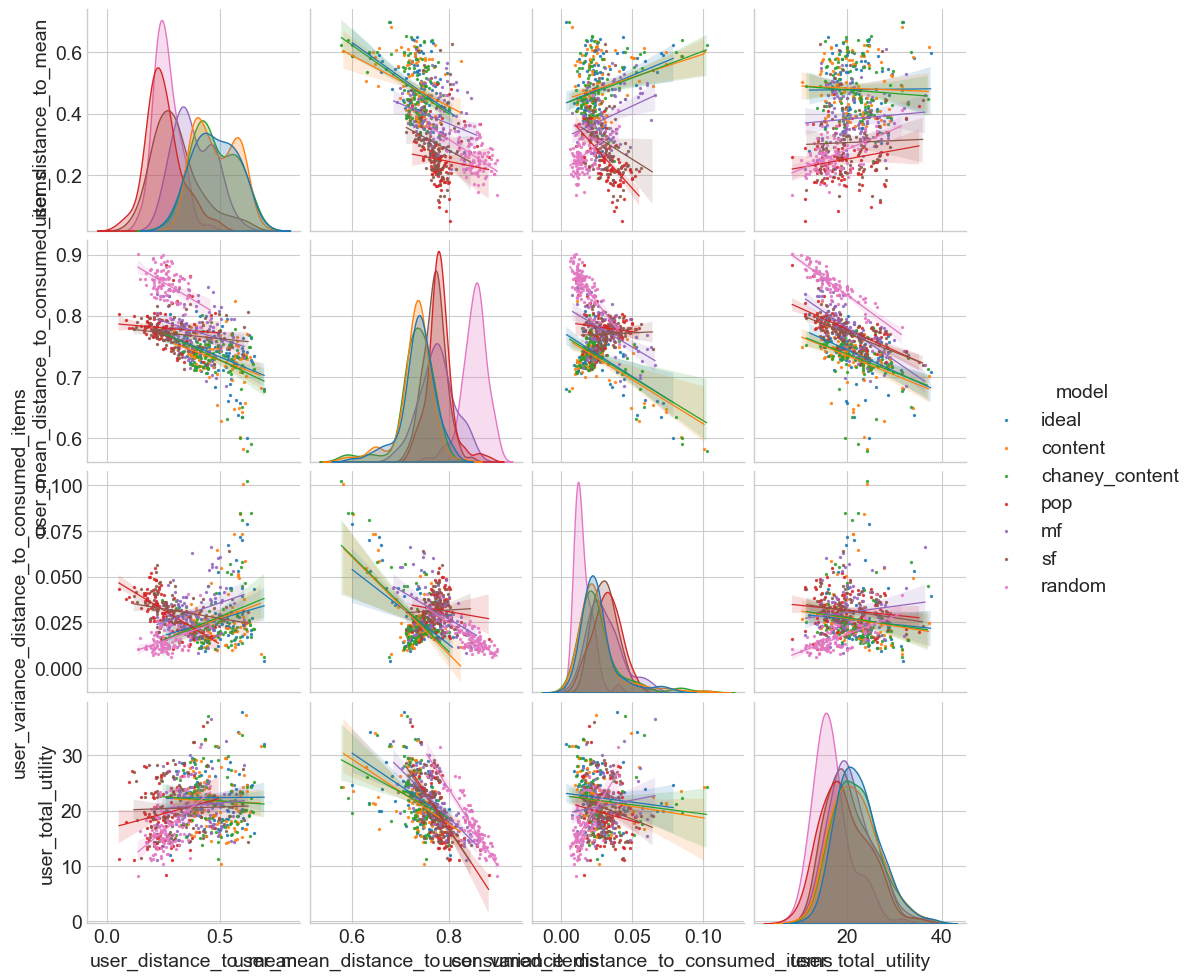

In [82]:
sns.pairplot(all_results[0], hue="model", kind="reg", plot_kws=dict(scatter_kws=dict(s=2), line_kws=dict(linewidth=0.9)))

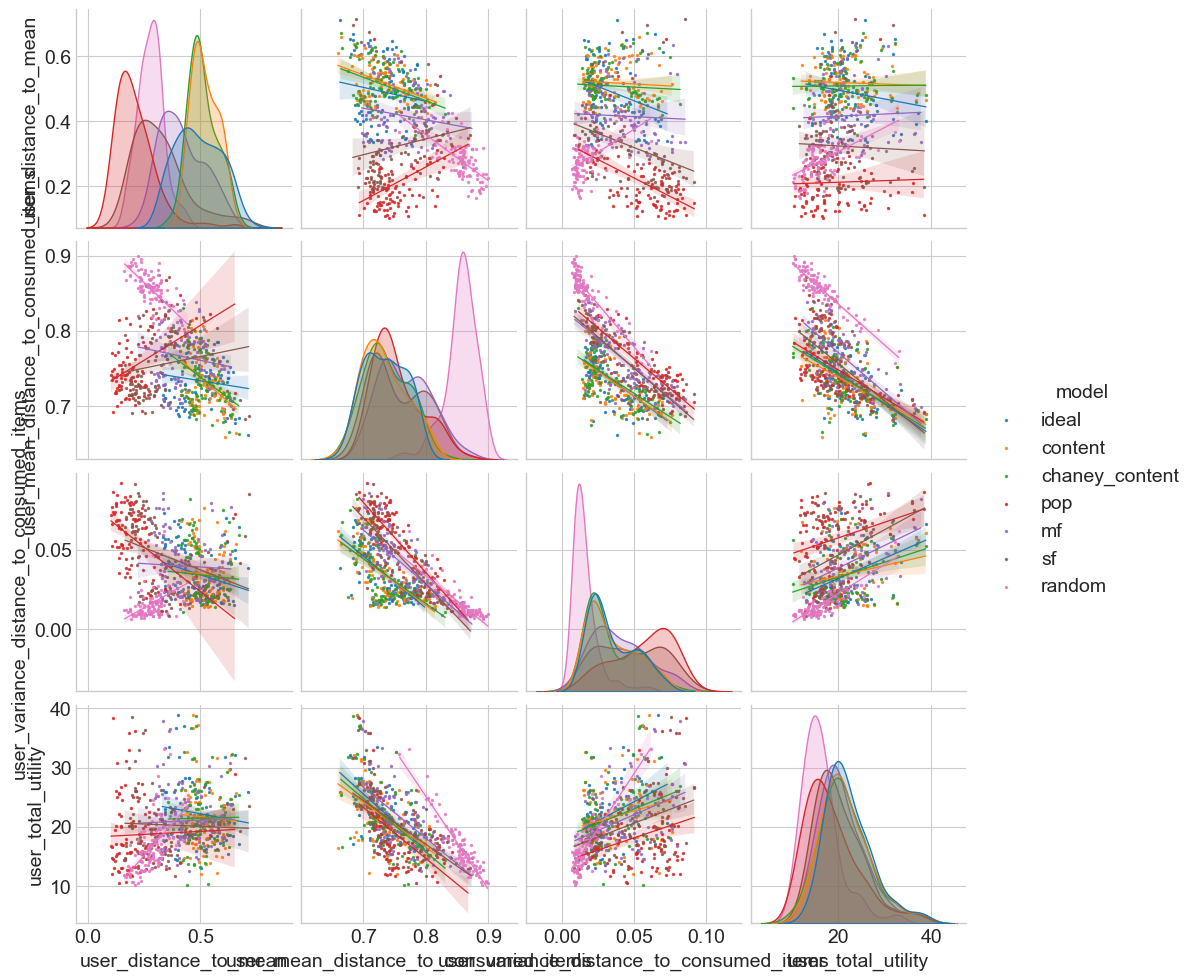

In [83]:
sns.pairplot(all_results[1], hue="model", kind="reg", plot_kws=dict(scatter_kws=dict(s=2), line_kws=dict(linewidth=0.9)))

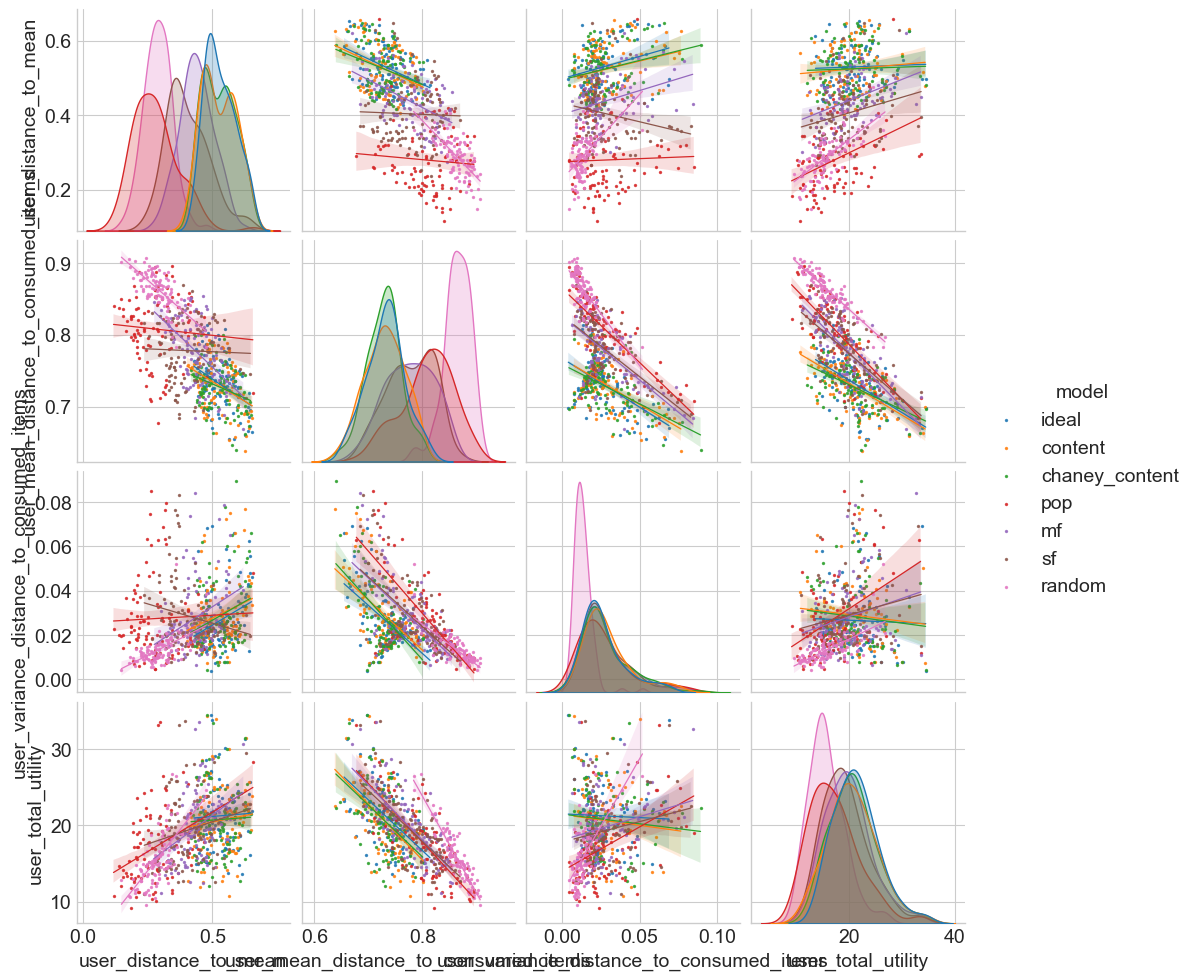

In [84]:
sns.pairplot(all_results[2], hue="model", kind="reg", plot_kws=dict(scatter_kws=dict(s=2), line_kws=dict(linewidth=0.9)))

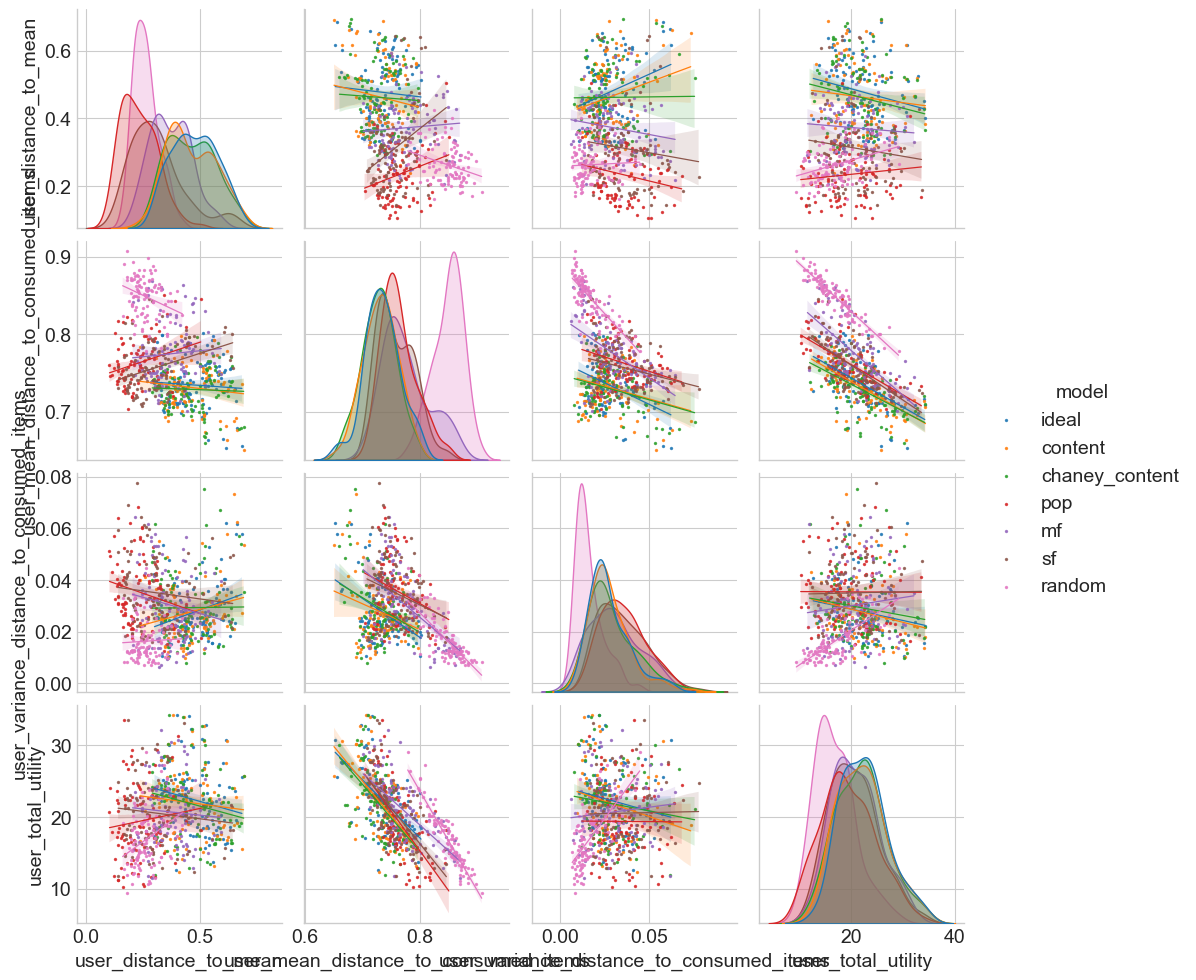

In [85]:
sns.pairplot(all_results[3], hue="model", kind="reg", plot_kws=dict(scatter_kws=dict(s=2), line_kws=dict(linewidth=0.9)))

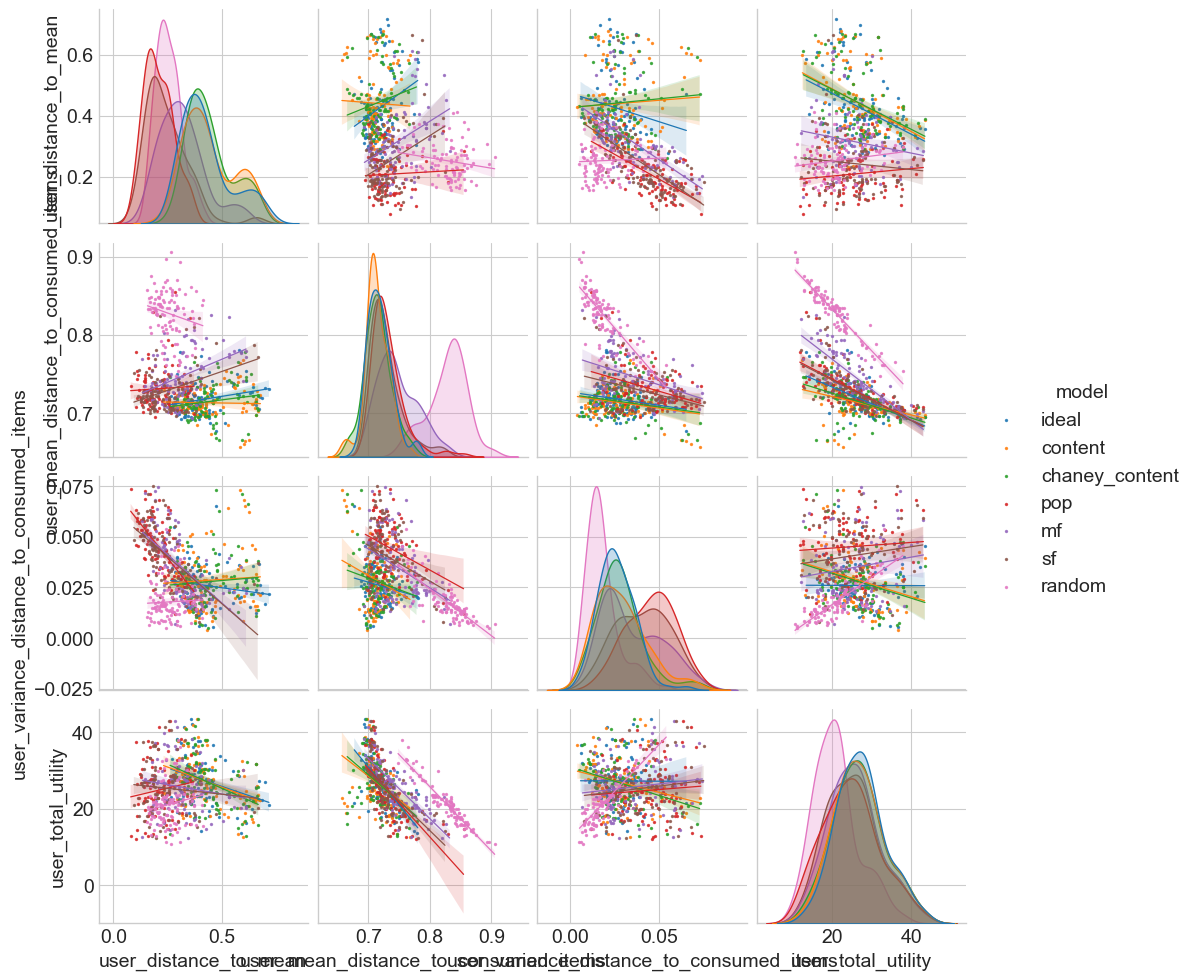

In [86]:
sns.pairplot(all_results[4], hue="model", kind="reg", plot_kws=dict(scatter_kws=dict(s=2), line_kws=dict(linewidth=0.9)))

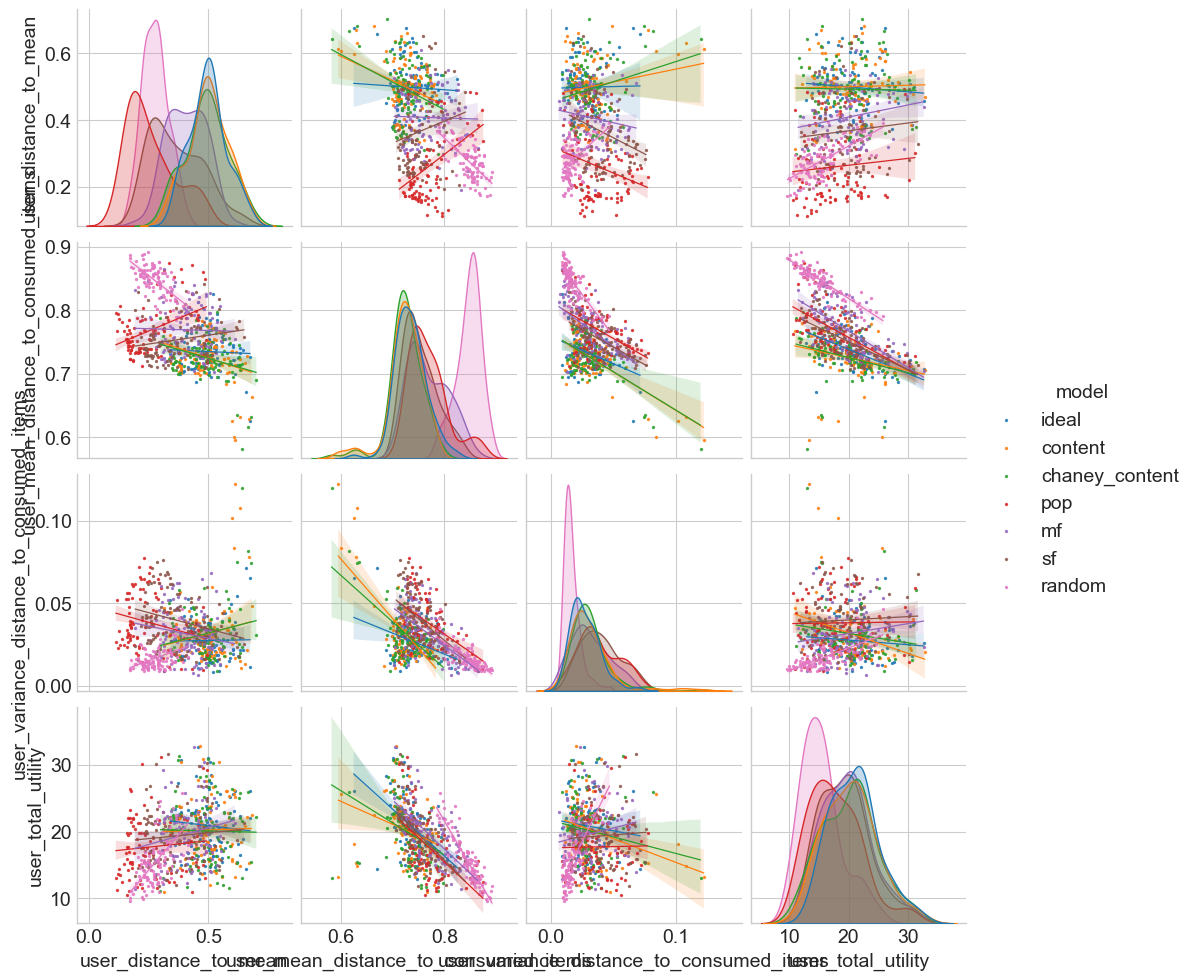

In [87]:
sns.pairplot(all_results[5], hue="model", kind="reg", plot_kws=dict(scatter_kws=dict(s=2), line_kws=dict(linewidth=0.9)))